In [2]:
import seaborn as sns
import os
import sqlite3
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('../data/preprocess/features.csv', index_col=0)
feature_cols = [c for c in df.columns if c != 'time_bucket_id']

print(df.shape)
df.head()

(255, 34)


,time_bucket_id,conn_count,unique_src_ips,unique_dst_ips,unique_dst_ports,total_orig_bytes,total_resp_bytes,avg_duration,failed_conns,tcp_count,...,snmp_count,snmp_get_requests,snmp_set_requests,dpd_count,tunnel_count,unique_tunnel_types,failed_conn_ratio,tcp_ratio,dns_per_http,snmp_write_ratio
0,0,597,236,34,230,6554.0,2294.0,1.194809,504,424,...,3.0,5.0,0.0,1.0,10.0,1.0,0.844221,0.710218,0.200000,0.0
1,2,1627,986,113,292,1340.0,2551.0,0.217099,1430,1282,...,1.0,2.0,0.0,0.0,6.0,1.0,0.878918,0.787953,0.375000,0.0
2,3,2023,1125,160,344,5733.0,8694.0,0.242910,1683,1421,...,3.0,4.0,0.0,0.0,2.0,1.0,0.831933,0.702422,0.461538,0.0
3,4,1665,973,124,319,1298.0,3144.0,0.229189,1368,1111,...,4.0,4.0,0.0,0.0,2.0,1.0,0.821622,0.667267,1.500000,0.0
4,5,1836,1015,117,340,3506.0,4282.0,0.607631,1471,1187,...,2.0,4.0,0.0,1.0,6.0,1.0,0.801198,0.646514,1.000000,0.0


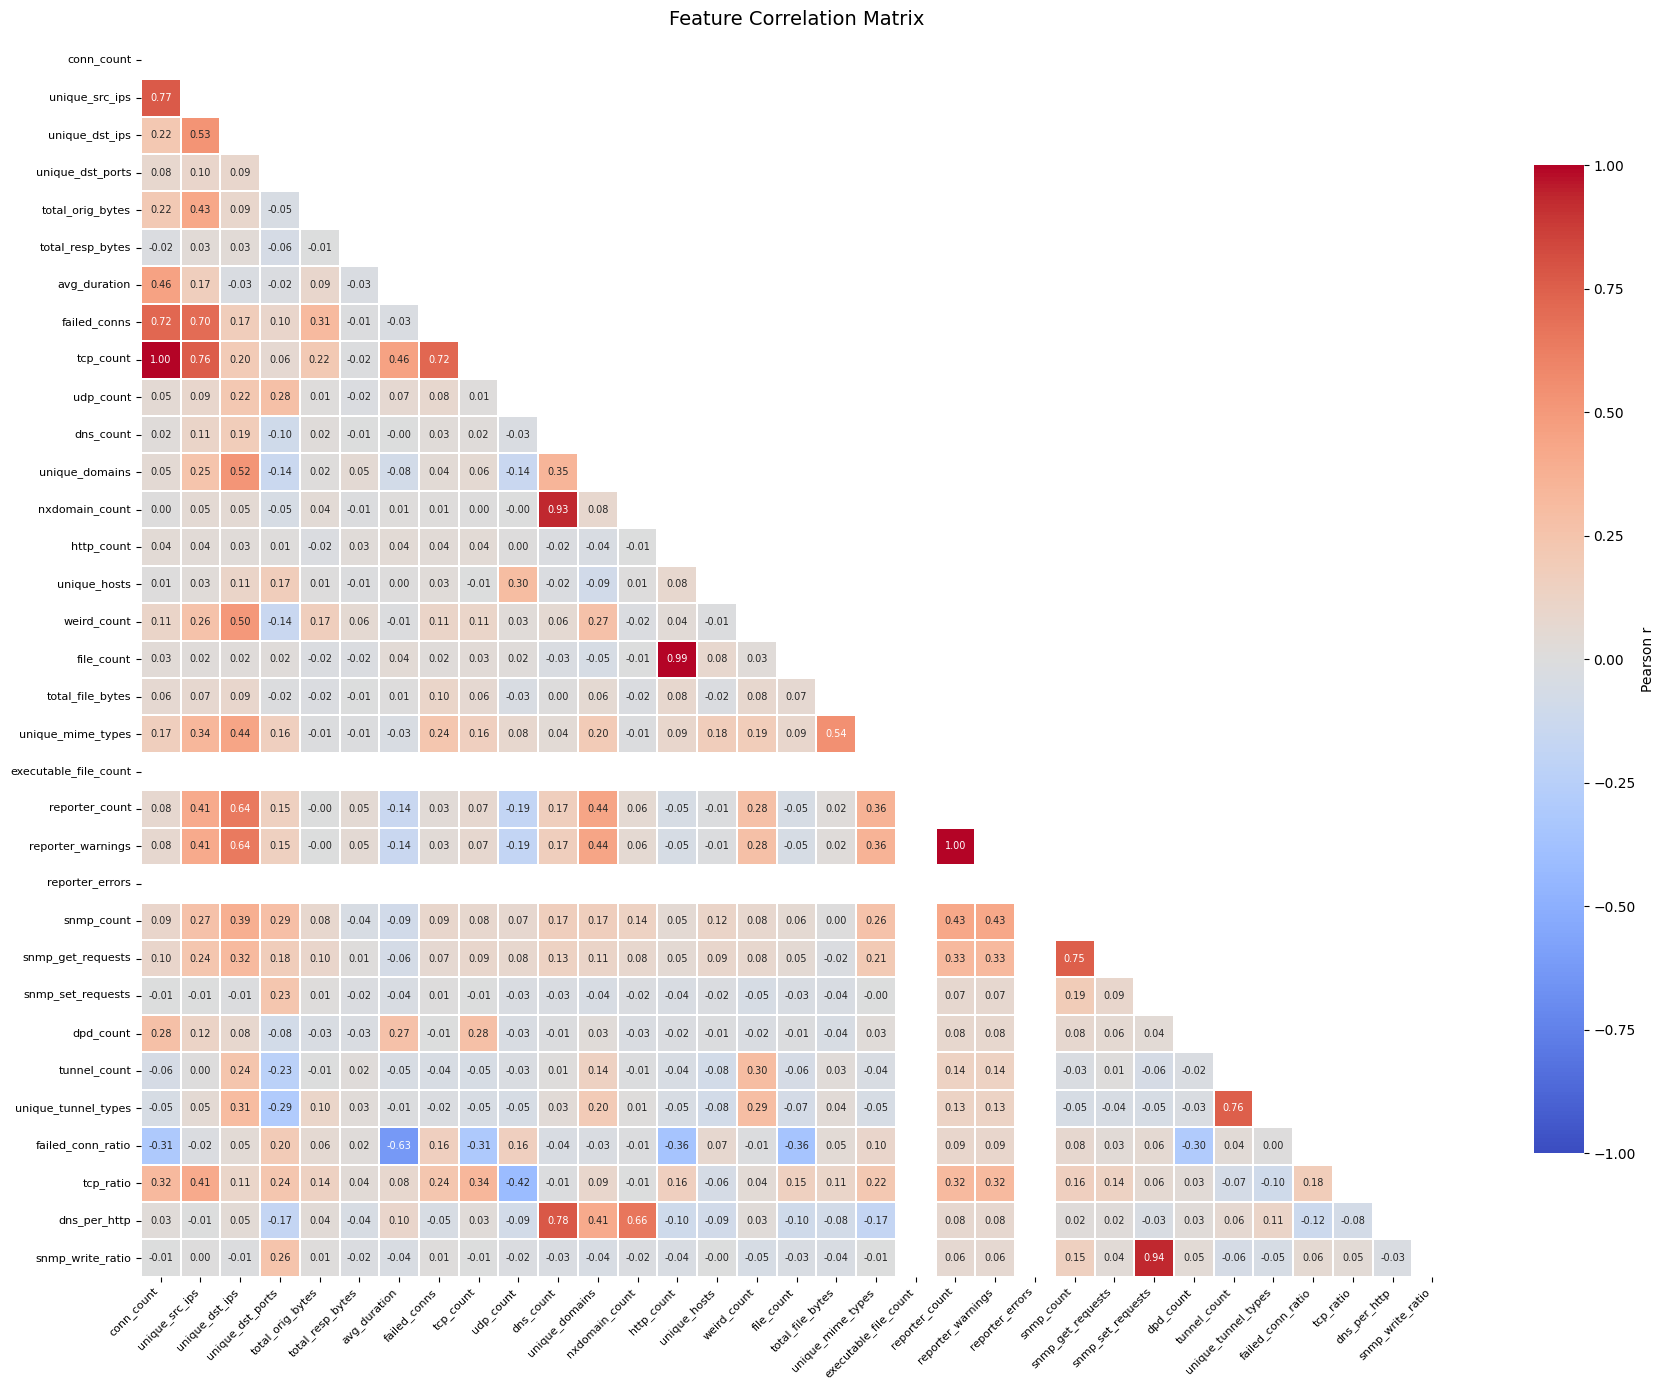

In [4]:
corr = df[feature_cols].corr()

# Mask the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
THRESHOLD = 0.75

# --- Step 1: find all highly correlated pairs ---
corr = df[feature_cols].corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool))

pairs = (
    corr.where(mask_upper == False)
        .stack()
        .reset_index()
)
pairs.columns = ['feature_a', 'feature_b', 'r']
pairs = pairs[pairs['r'].abs() >= THRESHOLD].sort_values('r', ascending=False, key=abs)

print(f"Correlated pairs (|r| >= {THRESHOLD}):")
print(pairs.to_string(index=False))
print()

Correlated pairs (|r| >= 0.75):
          feature_a         feature_b        r
  reporter_warnings    reporter_count 1.000000
          tcp_count        conn_count 0.998926
         file_count        http_count 0.994166
   snmp_write_ratio snmp_set_requests 0.936659
     nxdomain_count         dns_count 0.933170
       dns_per_http         dns_count 0.779730
     unique_src_ips        conn_count 0.765827
          tcp_count    unique_src_ips 0.758887
unique_tunnel_types      tunnel_count 0.756331
  snmp_get_requests        snmp_count 0.754343



In [6]:
# --- Step 2: greedy drop — for each correlated pair, drop the feature
# that appears most often as redundant. If tied, keep the one with more
# direct security meaning (defined in keep_preference below).
#
# Security preference reasoning:
#   failed_conn_ratio  > failed_conns     (normalized = more comparable across buckets)
#   tcp_ratio          > tcp_count        (normalized)
#   reporter_count     > reporter_warnings (count covers all severity levels)
#   conn_count         > tcp_count/udp_count (tcp+udp ~ conn, so sub-counts are redundant)
#   dns_count          > unique_domains   (count carries volume signal; unique_domains alone
#                                          is weaker without knowing total query volume)

to_drop = set()

for _, row in pairs.iterrows():
    a, b = row['feature_a'], row['feature_b']
    # Skip if one already scheduled for dropping
    if a in to_drop or b in to_drop:
        continue

    # Security-informed preference: which to keep
    keep_preference = {
        # (a, b) -> which to drop
        ('failed_conns',       'failed_conn_ratio'):  'failed_conns',
        ('tcp_count',          'tcp_ratio'):           'tcp_count',
        ('reporter_count',     'reporter_warnings'):   'reporter_warnings',
        ('tcp_count',          'conn_count'):          'tcp_count',
        ('udp_count',          'conn_count'):          'udp_count',
        ('tcp_count',          'udp_count'):           'udp_count',   # tcp_ratio more useful
    }

    drop_candidate = keep_preference.get((a, b)) or keep_preference.get((b, a))

    if drop_candidate:
        to_drop.add(drop_candidate)
    else:
        # Default: drop whichever has lower variance (less spread = less signal)
        drop_candidate = a if df[a].var() < df[b].var() else b
        to_drop.add(drop_candidate)

print(f"Dropping {len(to_drop)} correlated features: {sorted(to_drop)}")

Dropping 9 correlated features: ['dns_per_http', 'file_count', 'nxdomain_count', 'reporter_warnings', 'snmp_count', 'snmp_write_ratio', 'tcp_count', 'unique_src_ips', 'unique_tunnel_types']


In [7]:
# --- Step 3: also drop near-zero variance features with no semantic value ---
# Note: executable_file_count and snmp_set_requests are excluded here because
# they are semantically meaningful (any non-zero = suspicious) and handled
# separately as binary presence flags in the outlier analysis notebook.

VAR_THRESHOLD = 0.01
low_var = [
    c for c in feature_cols
    if df[c].var() < VAR_THRESHOLD
    and c not in {'executable_file_count', 'snmp_set_requests'}
    and c not in to_drop
]

print(f"Dropping {len(low_var)} near-zero variance features: {low_var}")
to_drop.update(low_var)

# --- Final reduced feature set ---
reduced_features = [c for c in feature_cols if c not in to_drop]
print(f"\nOriginal: {len(feature_cols)} features")
print(f"Dropped:  {len(to_drop)} features")
print(f"Kept:     {len(reduced_features)} features")
print(f"\nKept features:\n{reduced_features}")

df_reduced = df[['time_bucket_id'] + reduced_features]

Dropping 2 near-zero variance features: ['reporter_errors', 'tcp_ratio']

Original: 33 features
Dropped:  11 features
Kept:     22 features

Kept features:
['conn_count', 'unique_dst_ips', 'unique_dst_ports', 'total_orig_bytes', 'total_resp_bytes', 'avg_duration', 'failed_conns', 'udp_count', 'dns_count', 'unique_domains', 'http_count', 'unique_hosts', 'weird_count', 'total_file_bytes', 'unique_mime_types', 'executable_file_count', 'reporter_count', 'snmp_get_requests', 'snmp_set_requests', 'dpd_count', 'tunnel_count', 'failed_conn_ratio']


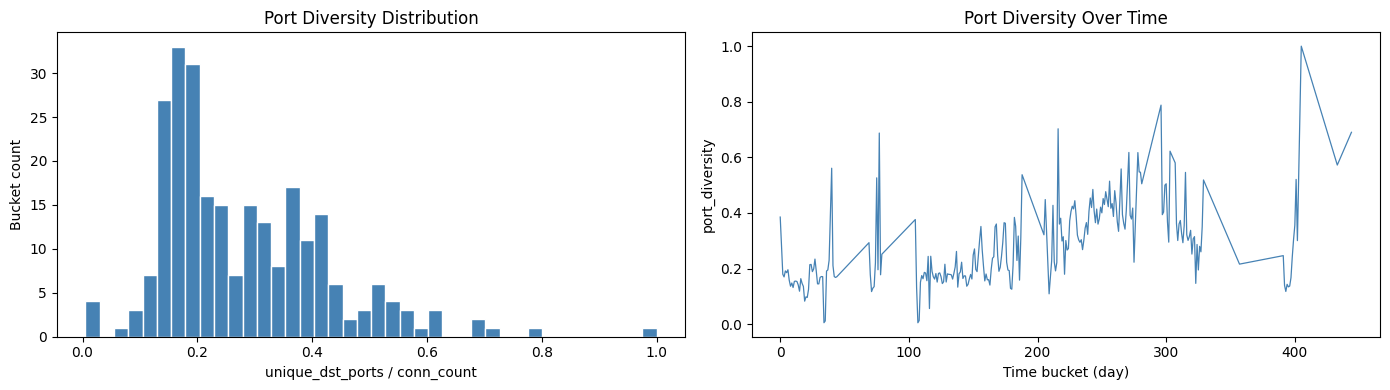

count    255.000000
mean       0.279502
std        0.145865
min        0.005080
25%        0.170991
50%        0.242411
75%        0.365155
max        1.000000
Name: port_diversity, dtype: float64


In [8]:
df['port_diversity'] = df['unique_dst_ports'] / df['conn_count'].replace(0, 1)

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['port_diversity'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Port Diversity Distribution')
axes[0].set_xlabel('unique_dst_ports / conn_count')
axes[0].set_ylabel('Bucket count')

axes[1].plot(df['time_bucket_id'], df['port_diversity'], linewidth=0.9, color='steelblue')
axes[1].set_title('Port Diversity Over Time')
axes[1].set_xlabel('Time bucket (day)')
axes[1].set_ylabel('port_diversity')

plt.tight_layout()
plt.show()

print(df['port_diversity'].describe())

In [9]:
df['executable_file_present'] = (df['executable_file_count'] > 0).astype(int)
df.drop(columns=['executable_file_count'], inplace=True)

print(df['executable_file_present'].value_counts())
print(f"\nBuckets with executables: {df['executable_file_present'].sum()}")

executable_file_present
0    255
Name: count, dtype: int64

Buckets with executables: 0


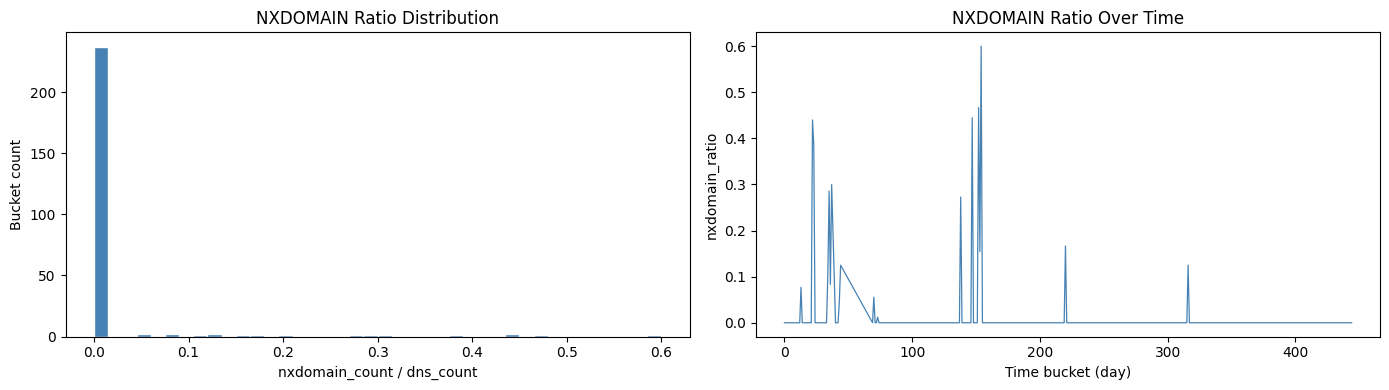

count    255.000000
mean       0.017037
std        0.075321
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.600000
Name: nxdomain_ratio, dtype: float64
Buckets with nxdomain_ratio > 0.5: 1
Dropped nxdomain_count. Remaining features: ['conn_count', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'total_orig_bytes', 'total_resp_bytes', 'avg_duration', 'failed_conns', 'tcp_count', 'udp_count', 'dns_count', 'unique_domains', 'http_count', 'unique_hosts', 'weird_count', 'file_count', 'total_file_bytes', 'unique_mime_types', 'reporter_count', 'reporter_warnings', 'reporter_errors', 'snmp_count', 'snmp_get_requests', 'snmp_set_requests', 'dpd_count', 'tunnel_count', 'unique_tunnel_types', 'failed_conn_ratio', 'tcp_ratio', 'dns_per_http', 'snmp_write_ratio', 'port_diversity', 'executable_file_present', 'nxdomain_ratio']


In [13]:
MIN_DNS = 5

df['nxdomain_ratio'] = np.where(
    df['dns_count'] >= MIN_DNS,
    df['nxdomain_count'] / df['dns_count'],
    0.0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['nxdomain_ratio'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('NXDOMAIN Ratio Distribution')
axes[0].set_xlabel('nxdomain_count / dns_count')
axes[0].set_ylabel('Bucket count')

axes[1].plot(df['time_bucket_id'], df['nxdomain_ratio'], linewidth=0.9, color='steelblue')
axes[1].set_title('NXDOMAIN Ratio Over Time')
axes[1].set_xlabel('Time bucket (day)')
axes[1].set_ylabel('nxdomain_ratio')

plt.tight_layout()
plt.show()

print(df['nxdomain_ratio'].describe())
print(f"Buckets with nxdomain_ratio > 0.5: {(df['nxdomain_ratio'] > 0.5).sum()}")
df.drop(columns=['nxdomain_count'], inplace=True)
print(f"Dropped nxdomain_count. Remaining features: {[c for c in df.columns if c != 'time_bucket_id']}")


In [24]:
total = df['total_orig_bytes'] + df['total_resp_bytes']

# 1. Traffic asymmetry: +1 = all outbound (exfiltration), -1 = all inbound (C2 download), ~0 = normal
df['traffic_asymmetry'] = (df['total_orig_bytes'] - df['total_resp_bytes']) / total.replace(0, 1)

# 2. Total bytes: preserves volume signal that asymmetry alone loses
df['total_bytes'] = total

# 3. Source concentration: low = few IPs making many connections (scanner/botnet)
df['src_concentration'] = df['unique_src_ips'] / df['conn_count'].replace(0, 1)

# 4. Weird rate: protocol anomalies normalized by traffic volume
df['weird_rate'] = df['weird_count'] / df['conn_count'].replace(0, 1)

# 5. DNS to connection ratio: more direct than dns_per_http
df['dns_to_conn_ratio'] = df['dns_count'] / df['conn_count'].replace(0, 1)

# Drop the raw columns that are now fully captured by the combined features
df.drop(columns=['total_orig_bytes', 'total_resp_bytes', 'weird_count', 'dns_per_http'], inplace=True)

print(f"Features after combining: {[c for c in df.columns if c != 'time_bucket_id']}")
df.head()

Features after combining: ['conn_count', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'avg_duration', 'failed_conns', 'tcp_count', 'udp_count', 'dns_count', 'unique_domains', 'http_count', 'unique_hosts', 'file_count', 'total_file_bytes', 'unique_mime_types', 'reporter_count', 'snmp_count', 'snmp_get_requests', 'snmp_set_requests', 'dpd_count', 'tunnel_count', 'unique_tunnel_types', 'failed_conn_ratio', 'tcp_ratio', 'snmp_write_ratio', 'port_diversity', 'executable_file_present', 'nxdomain_ratio', 'traffic_asymmetry', 'total_bytes', 'src_concentration', 'weird_rate', 'dns_to_conn_ratio']


,time_bucket_id,conn_count,unique_src_ips,unique_dst_ips,unique_dst_ports,avg_duration,failed_conns,tcp_count,udp_count,dns_count,...,tcp_ratio,snmp_write_ratio,port_diversity,executable_file_present,nxdomain_ratio,traffic_asymmetry,total_bytes,src_concentration,weird_rate,dns_to_conn_ratio
0,0,597,236,34,230,1.194809,504,424,85,1.0,...,0.710218,0.0,0.385260,0,0.0,0.481465,8848.0,0.395310,0.003350,0.001675
1,2,1627,986,113,292,0.217099,1430,1282,160,3.0,...,0.787953,0.0,0.179471,0,0.0,-0.311231,3891.0,0.606023,0.015980,0.001844
2,3,2023,1125,160,344,0.242910,1683,1421,287,12.0,...,0.702422,0.0,0.170044,0,0.0,-0.205240,14427.0,0.556105,0.009392,0.005932
3,4,1665,973,124,319,0.229189,1368,1111,262,9.0,...,0.667267,0.0,0.191592,0,0.0,-0.415579,4442.0,0.584384,0.005405,0.005405
4,5,1836,1015,117,340,0.607631,1471,1187,316,15.0,...,0.646514,0.0,0.185185,0,0.0,-0.099640,7788.0,0.552832,0.006536,0.008170


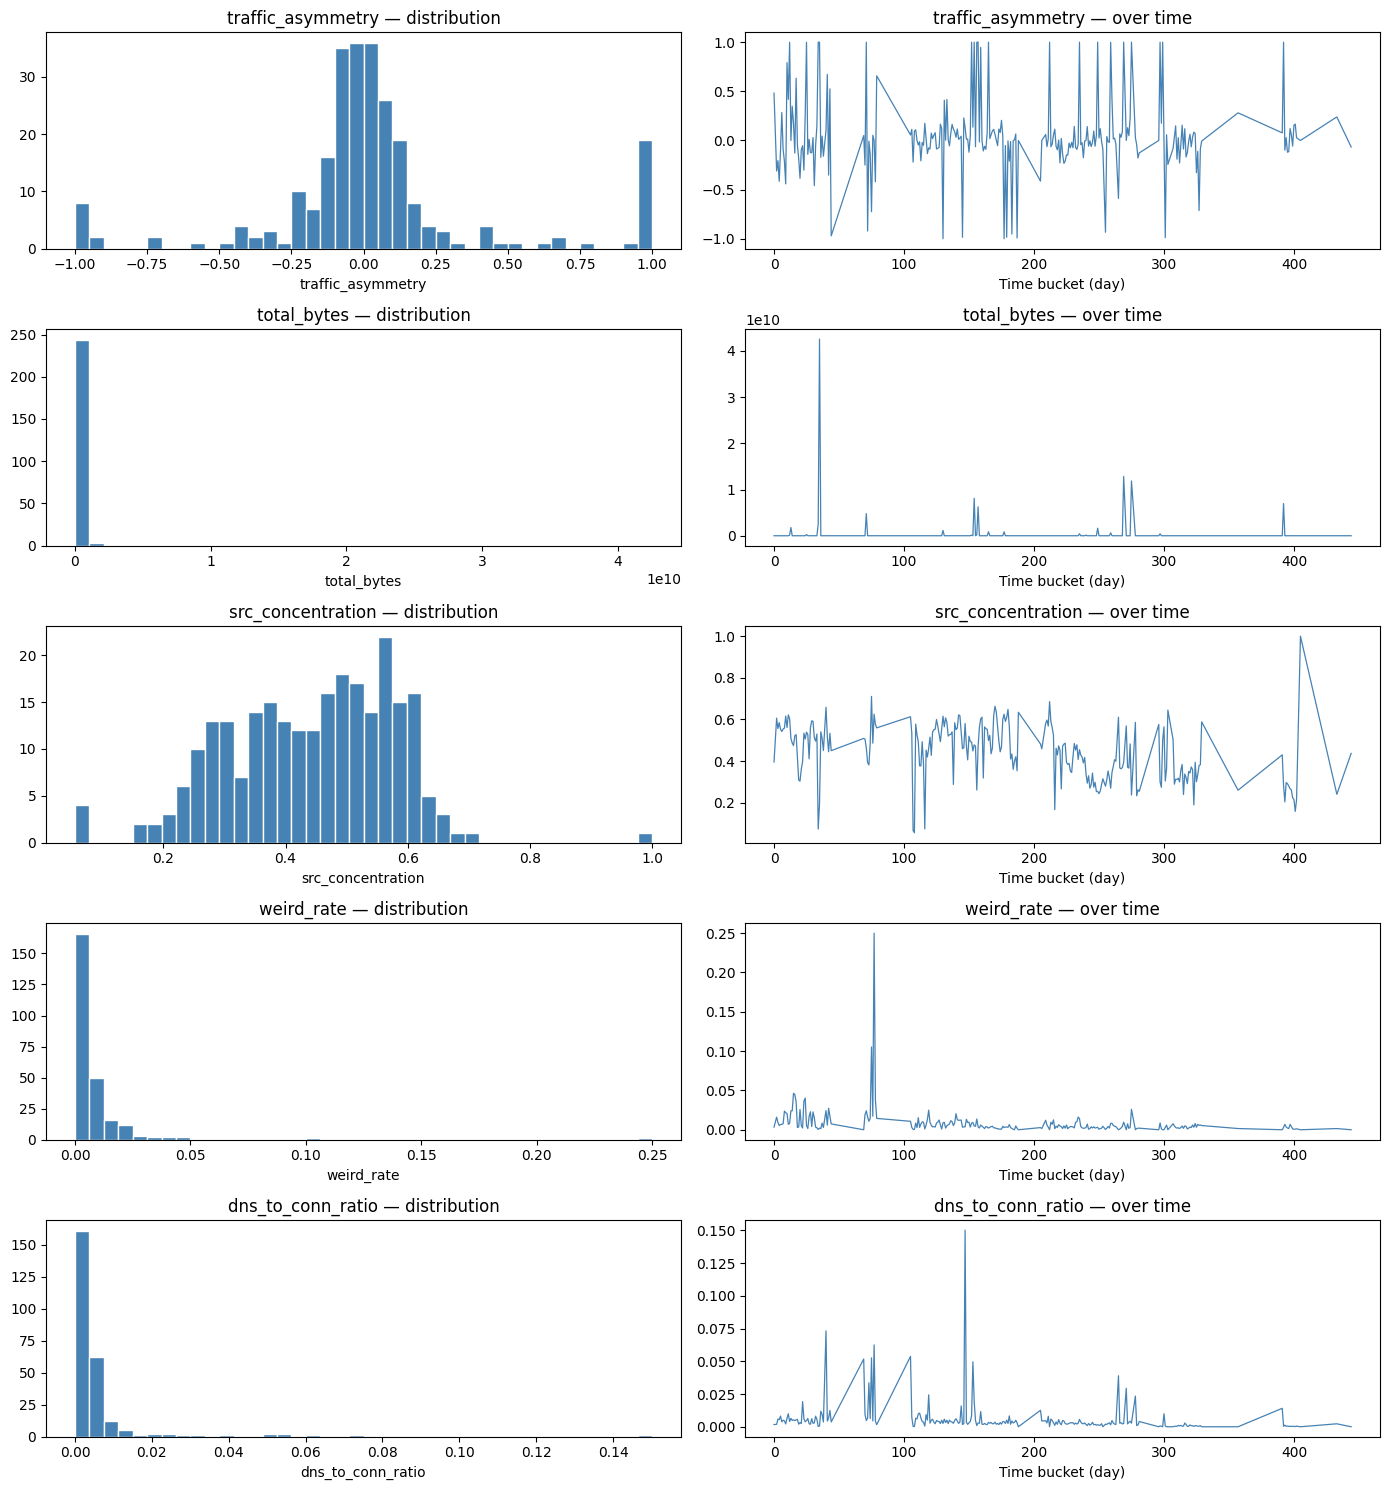

In [25]:
new_features = ['traffic_asymmetry', 'total_bytes', 'src_concentration', 'weird_rate', 'dns_to_conn_ratio']

fig, axes = plt.subplots(len(new_features), 2, figsize=(14, len(new_features) * 3))

for i, col in enumerate(new_features):
    axes[i, 0].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — distribution')
    axes[i, 0].set_xlabel(col)

    axes[i, 1].plot(df['time_bucket_id'], df[col], linewidth=0.9, color='steelblue')
    axes[i, 1].set_title(f'{col} — over time')
    axes[i, 1].set_xlabel('Time bucket (day)')

plt.tight_layout()
plt.show()

In [26]:
to_drop = [
    'reporter_warnings',   # subset of reporter_count
    'unique_hosts',        # highly correlated with http_count
    'unique_mime_types',   # near-constant, almost always 2
    'dpd_count',           # very sparse, no clear security meaning
    'unique_tunnel_types', # almost always 1, tunnel_count covers it
    'tcp_count',           # conn_count * tcp_ratio reconstructs this exactly
    'udp_count',           # same
    'snmp_get_requests',   # covered by snmp_count + snmp_write_ratio
    'snmp_set_requests',   # same
]

cols_to_drop = [c for c in to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

final_features = [c for c in df.columns if c != 'time_bucket_id']
print(f"Dropped {len(cols_to_drop)} features. {len(final_features)} remaining:")
print(final_features)


Dropped 8 features. 25 remaining:
['conn_count', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'avg_duration', 'failed_conns', 'dns_count', 'unique_domains', 'http_count', 'file_count', 'total_file_bytes', 'reporter_count', 'snmp_count', 'tunnel_count', 'failed_conn_ratio', 'tcp_ratio', 'snmp_write_ratio', 'port_diversity', 'executable_file_present', 'nxdomain_ratio', 'traffic_asymmetry', 'total_bytes', 'src_concentration', 'weird_rate', 'dns_to_conn_ratio']


In [27]:
df.to_csv('../data/preprocess/features_final.csv', index=False)
print(f"Saved {len(final_features)} features, {len(df)} rows → data/preprocess/features_final.csv")

Saved 25 features, 255 rows → data/preprocess/features_final.csv
